# Identifying Walkability-Related Studies in Smart City Research
## Embedding Similarity + Zero-Shot Classification (replaces the fine-tuned DeBERTa pipeline)

Este notebook substitui `05_GenAI_Classification.ipynb`. Em vez do DeBERTa fine-tuned
(que memorizou os dados sintéticos e colapsou para recall ~0.245 nos abstracts reais),
usamos dois métodos que não dependem de treino em dados sintéticos:

1. **Embedding similarity** — similaridade de cosseno entre o embedding do texto e o
   embedding de uma frase-âncora ("this article uses sensor data to measure walkability").
2. **Zero-shot classification (NLI)** — um classificador zero-shot pré-treinado avalia a
   mesma pergunta como hipótese, sem nenhum treino específico no seu domínio.

**Pipeline:**
- Passo 1: rodar os dois métodos no `real.json` (conjunto real adjudicado, ~67 abstracts)
  para obter métricas (recall, precision, F1, WSS@95) e calibrar o threshold de decisão.
- Passo 2: aplicar os métodos calibrados no corpus completo (o mesmo arquivo usado pelo
  notebook original, `04_document_search_results_with_intros_and_contributions.json`).
- Passo 3: salvar os resultados (scores completos + subconjunto filtrado).

> **Nota:** este notebook foi construído a partir da estrutura do notebook original que
> você enviou, mas eu não tenho acesso ao seu `real.json` nem ao arquivo `04_...json`
> neste ambiente — então os caminhos, nomes de campos e formatos abaixo são inferidos e
> ficam centralizados na seção CONFIG. Rode localmente e ajuste o que não bater (o
> notebook imprime diagnósticos claros se um campo esperado não existir).

In [1]:
# Import Required Libraries
import json
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import torch
from sentence_transformers import SentenceTransformer, util
from transformers import pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    auc,
)

pd.set_option("display.max_colwidth", 100)
sns.set(style="whitegrid")
plt.rcParams.update({"font.size": 12})
plt.rcParams.update({"font.family": "Times New Roman"})

os.environ["TOKENIZERS_PARALLELISM"] = "false"

DEVICE = 0 if torch.cuda.is_available() else -1
TORCH_DEVICE = torch.device("cuda" if torch.cuda.is_available() else
                             "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {TORCH_DEVICE}")

Using device: cuda


## Configuration

Ajuste estes caminhos e nomes de campo antes de rodar. Os defaults seguem a convenção
do notebook original (`../data/...`) e o nome de campo `contribution` que ele usa para
o texto classificado.

- `REAL_DATA_PATH`: o `real.json` com os ~67 abstracts adjudicados (rótulo humano).
- `MAIN_DATA_PATH`: o corpus completo, mesmo arquivo do notebook original.
- `TEXT_FIELD_CANDIDATES`: nomes de campo tentados, em ordem, para extrair o texto de
  cada registro (tenta o primeiro que existir e não for vazio).
- `LABEL_FIELD_CANDIDATES`: idem, para o rótulo humano no `real.json`.
- `POSITIVE_LABEL_VALUES`: quais valores de rótulo contam como positivo (ajuste se o
  seu `real.json` usa 1/0, True/False, "positive"/"negative", etc. — todos os
  candidatos abaixo são tentados).

In [2]:
CONFIG = {
    "REAL_DATA_PATH": "../model/dataset/real.json",
    "MAIN_DATA_PATH": "../data/04_document_search_results_with_intros_and_contributions.json",

    "TEXT_FIELD_CANDIDATES": ["contribution", "abstract", "text", "contribution_text"],
    "LABEL_FIELD_CANDIDATES": ["label", "is_walkability_related", "walkability", "y", "class"],
    "POSITIVE_LABEL_VALUES": {
        1, "1", True, "true", "True", "positive", "Positive", "yes", "Yes",
        "related", "Related", "walkability-related", "walkability related",
        "sensing of walkability dimension", "Sensing of walkability dimension",
    },

    "EMBEDDING_MODEL_NAME": "sentence-transformers/all-mpnet-base-v2",
    # Same zero-shot model already referenced (commented out) in the original notebook,
    # kept for continuity with earlier experimentation in this project.
    "ZEROSHOT_MODEL_NAME": "MoritzLaurer/deberta-v3-large-zeroshot-v2.0-c",

    # Anchor phrase used both as the embedding-similarity target and (via
    # hypothesis_template) as the zero-shot NLI hypothesis.
    "POSITIVE_ANCHOR": "This article uses data from a sensor to measure walkability.",
    "NEGATIVE_ANCHOR": "This article does not use sensor data to measure walkability.",

    "ZEROSHOT_CANDIDATE_LABELS": [
        "uses sensor data to measure a walkability dimension",
        "does not use sensor data to measure walkability",
    ],
    "ZEROSHOT_HYPOTHESIS_TEMPLATE": "This article {}.",

    # Screening threshold is calibrated to hit at least this recall on real.json,
    # consistent with the WSS@95 benchmark already used elsewhere in the project.
    "TARGET_RECALL": 0.95,

    "OUTPUT_DIR": "../data",
}

os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)

## Helper functions

`get_text` tenta os campos candidatos em ordem. `get_label` normaliza o rótulo humano
para 0/1. `wss_at_recall` implementa Work Saved over Sampling no ponto de recall alvo
(Cohen et al., 2006): `WSS@X = (TN + FN) / N - (1 - X)`, calculado no threshold mais
baixo que ainda garante recall >= X.

In [3]:
def get_text(record, field_candidates=CONFIG["TEXT_FIELD_CANDIDATES"]):
    for field in field_candidates:
        val = record.get(field)
        if isinstance(val, str) and val.strip():
            return val.strip()
    return None


def get_label(record, field_candidates=CONFIG["LABEL_FIELD_CANDIDATES"],
              positive_values=CONFIG["POSITIVE_LABEL_VALUES"]):
    for field in field_candidates:
        if field in record and record[field] is not None:
            value = record[field]
            if isinstance(value, str):
                normalized = value.strip().lower()
                positive_text = {
                    "1", "true", "yes", "positive", "related",
                    "walkability-related", "walkability related",
                    "sensing of walkability dimension",
                    "sensor-based walkability",
                    "sensor data to measure walkability",
                }
                negative_text = {
                    "0", "false", "no", "negative", "not related",
                    "not-related", "not walkability related",
                    "non-related", "unrelated",
                }
                if normalized in positive_text:
                    return 1
                if normalized in negative_text:
                    return 0
                if "related" in normalized and "not" not in normalized:
                    return 1
                if "not related" in normalized or "unrelated" in normalized:
                    return 0
            return 1 if value in positive_values else 0
    return None


def _confusion_counts(y_true, y_pred):
    """Return tn, fp, fn, tp robustly for single-class or empty-positive cases."""
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape == (1, 1):
        label = y_true[0] if len(y_true) else 0
        if label == 1:
            tn, fp, fn, tp = 0, 0, 0, len(y_pred)
        else:
            tn, fp, fn, tp = len(y_pred), 0, 0, 0
        return tn, fp, fn, tp

    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        return tn, fp, fn, tp

    if cm.shape == (1, 2):
        # Only positive predictions exist (all labels are positive)
        tn, fp, fn, tp = 0, 0, 0, int(np.sum(y_pred))
        return tn, fp, fn, tp

    if cm.shape == (2, 1):
        # Only negative predictions exist (all labels are negative)
        tn, fp, fn, tp = int(np.sum(1 - y_true)), 0, 0, 0
        return tn, fp, fn, tp

    raise ValueError(f"Unexpected confusion matrix shape: {cm.shape}")


def threshold_for_target_recall(y_true, scores, target_recall):
    """Lowest score threshold such that recall on y_true >= target_recall."""
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    if y_true.size == 0:
        raise ValueError("Cannot evaluate on an empty label array.")

    positives = np.sum(y_true == 1)
    if positives == 0:
        # No positive labels available; reporting metrics is meaningless, but a
        # conservative threshold still lets the code continue without crashing.
        warnings.warn(
            "No positive samples in y_true; precision/recall/F1 are undefined. "
            "Using a threshold of 0.0 to allow the notebook to continue.",
            UserWarning,
        )
        return 0.0, 0.0

    fpr, tpr, thresholds = roc_curve(y_true, scores)
    valid = tpr >= target_recall
    if not valid.any():
        # Target recall not reachable; fall back to the threshold giving max recall
        best_idx = int(np.argmax(tpr))
        return thresholds[best_idx], tpr[best_idx]
    # Among thresholds achieving target recall, pick the one maximizing precision
    # (i.e., the highest threshold still satisfying the recall constraint)
    candidate_idxs = np.where(valid)[0]
    best_idx = candidate_idxs[np.argmax(thresholds[candidate_idxs])]
    return thresholds[best_idx], tpr[best_idx]


def wss_at_recall(y_true, scores, target_recall):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    thr, achieved_recall = threshold_for_target_recall(y_true, scores, target_recall)
    y_pred = (scores >= thr).astype(int)
    tn, fp, fn, tp = _confusion_counts(y_true, y_pred)
    n = len(y_true)
    if np.sum(y_true == 1) == 0:
        wss = 0.0
    else:
        wss = (tn + fn) / n - (1 - target_recall)
    return {
        "threshold": float(thr),
        "achieved_recall": float(achieved_recall),
        "wss_at_target": float(wss),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


def evaluate_scores(y_true, scores, target_recall, method_name):
    stats = wss_at_recall(y_true, scores, target_recall)
    y_pred = (np.asarray(scores) >= stats["threshold"]).astype(int)
    print(f"=== {method_name} — evaluated at threshold {stats['threshold']:.4f} "
          f"(target recall {target_recall:.0%}) ===")
    if np.sum(np.asarray(y_true) == 1) == 0:
        print("Warning: no positive samples in y_true; classification_report is not meaningful.")
        print(f"WSS@{int(target_recall*100)}: {stats['wss_at_target']:.3f}  "
              f"(achieved recall: {stats['achieved_recall']:.3f})")
        return stats
    print(classification_report(y_true, y_pred, target_names=["not related", "related"], digits=3))
    print(f"WSS@{int(target_recall*100)}: {stats['wss_at_target']:.3f}  "
          f"(achieved recall: {stats['achieved_recall']:.3f})")
    return stats

## Step 1 — Load the real labeled set (`real.json`)

Este é o conjunto adjudicado (~67 abstracts, ~20 positivos / ~47 negativos) usado para
medir a performance real dos métodos — o mesmo papel que os "real diagnostic abstracts"
tiveram na avaliação do DeBERTa.

In [4]:
with open(CONFIG["REAL_DATA_PATH"], "r", encoding="utf8") as f:
    real_data = json.load(f)

df_real = pd.DataFrame(real_data)
df_real["text"] = df_real.apply(lambda r: get_text(r.to_dict()), axis=1)
df_real["label"] = df_real.apply(lambda r: get_label(r.to_dict()), axis=1)

missing_text = df_real["text"].isna().sum()
missing_label = df_real["label"].isna().sum()
if missing_text:
    print(f"WARNING: {missing_text} records have no text in any of "
          f"{CONFIG['TEXT_FIELD_CANDIDATES']} — check CONFIG['TEXT_FIELD_CANDIDATES'].")
if missing_label:
    print(f"WARNING: {missing_label} records have no recognizable label in any of "
          f"{CONFIG['LABEL_FIELD_CANDIDATES']} — check CONFIG['LABEL_FIELD_CANDIDATES'] "
          f"and CONFIG['POSITIVE_LABEL_VALUES'].")

df_real = df_real.dropna(subset=["text", "label"]).reset_index(drop=True)
df_real["label"] = df_real["label"].astype(int)

print(f"Loaded {len(df_real)} labeled real records "
      f"({df_real['label'].sum()} positive, {(df_real['label']==0).sum()} negative)")
df_real.head(3)

Loaded 100 labeled real records (46 positive, 54 negative)


,text,label
0,Associations between park and playground availability and proximity and children’s physical acti...,0
1,"Urban form, children's active travel to/from school, and travel related physical activity. Child...",0
2,Enhancing mapping precision in autonomous delivery robots through tightly-coupled fusion of unce...,0


## Part A — Embedding similarity

Codificamos cada abstract e a frase-âncora positiva com um sentence-transformer, e
usamos a similaridade de cosseno como score contínuo. O threshold é calibrado no
`real.json` para atingir o recall alvo (`TARGET_RECALL`).

In [5]:
print("Loading embedding model...")
embed_model = SentenceTransformer(CONFIG["EMBEDDING_MODEL_NAME"], device=str(TORCH_DEVICE))

positive_anchor_emb = embed_model.encode(CONFIG["POSITIVE_ANCHOR"], convert_to_tensor=True)

def embedding_score(text):
    text_emb = embed_model.encode(text, convert_to_tensor=True)
    return util.cos_sim(text_emb, positive_anchor_emb).item()

tqdm.pandas(desc="Embedding similarity (real.json)")
df_real["embedding_score"] = df_real["text"].progress_apply(embedding_score)
df_real[["text", "label", "embedding_score"]].head(3)

Loading embedding model...


Embedding similarity (real.json):   0%|          | 0/100 [00:00<?, ?it/s]

,text,label,embedding_score
0,Associations between park and playground availability and proximity and children’s physical acti...,0,0.497046
1,"Urban form, children's active travel to/from school, and travel related physical activity. Child...",0,0.644272
2,Enhancing mapping precision in autonomous delivery robots through tightly-coupled fusion of unce...,0,0.380519


In [6]:
embedding_stats = evaluate_scores(
    df_real["label"], df_real["embedding_score"], CONFIG["TARGET_RECALL"], "Embedding similarity"
)

=== Embedding similarity — evaluated at threshold 0.3940 (target recall 95%) ===
              precision    recall  f1-score   support

 not related      0.920     0.426     0.582        54
     related      0.587     0.957     0.727        46

    accuracy                          0.670       100
   macro avg      0.753     0.691     0.655       100
weighted avg      0.767     0.670     0.649       100

WSS@95: 0.200  (achieved recall: 0.957)


## Part B — Zero-shot classification (NLI)

Usamos um classificador zero-shot com a mesma pergunta formulada como hipótese NLI
(`ZEROSHOT_HYPOTHESIS_TEMPLATE` + `ZEROSHOT_CANDIDATE_LABELS`). O score é a
probabilidade atribuída ao rótulo positivo. Threshold calibrado da mesma forma.

In [7]:
print("Loading zero-shot classifier...")
zeroshot_classifier = pipeline(
    "zero-shot-classification",
    model=CONFIG["ZEROSHOT_MODEL_NAME"],
    device=DEVICE,
)

POSITIVE_LABEL = CONFIG["ZEROSHOT_CANDIDATE_LABELS"][0]

def zeroshot_score(text):
    result = zeroshot_classifier(
        text,
        candidate_labels=CONFIG["ZEROSHOT_CANDIDATE_LABELS"],
        hypothesis_template=CONFIG["ZEROSHOT_HYPOTHESIS_TEMPLATE"],
        multi_label=False,
    )
    label_to_score = dict(zip(result["labels"], result["scores"]))
    return label_to_score.get(POSITIVE_LABEL, 0.0)

tqdm.pandas(desc="Zero-shot classification (real.json)")
df_real["zeroshot_score"] = df_real["text"].progress_apply(zeroshot_score)
df_real[["text", "label", "zeroshot_score"]].head(3)

Loading zero-shot classifier...


Device set to use cuda:0


Zero-shot classification (real.json):   0%|          | 0/100 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,text,label,zeroshot_score
0,Associations between park and playground availability and proximity and children’s physical acti...,0,0.150465
1,"Urban form, children's active travel to/from school, and travel related physical activity. Child...",0,0.979196
2,Enhancing mapping precision in autonomous delivery robots through tightly-coupled fusion of unce...,0,0.044618


In [8]:
zeroshot_stats = evaluate_scores(
    df_real["label"], df_real["zeroshot_score"], CONFIG["TARGET_RECALL"], "Zero-shot classification"
)

=== Zero-shot classification — evaluated at threshold 0.0421 (target recall 95%) ===
              precision    recall  f1-score   support

 not related      0.857     0.222     0.353        54
     related      0.512     0.957     0.667        46

    accuracy                          0.560       100
   macro avg      0.684     0.589     0.510       100
weighted avg      0.698     0.560     0.497       100

WSS@95: 0.090  (achieved recall: 0.957)


## Comparing the two methods

ROC de cada método no `real.json`, e uma tabela lado a lado com as métricas no
threshold calibrado. Isso é o que decide (ou justifica um ensemble) qual método vai
para o corpus completo — e é o registro que documenta a validação no protocolo PRISMA.

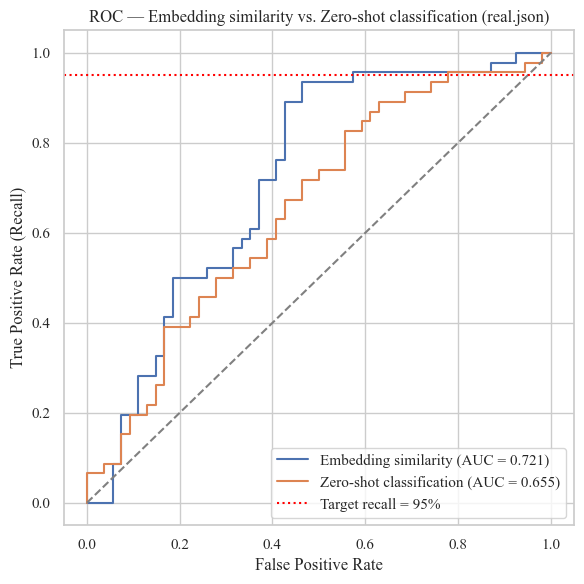

Embedding similarity on real.json -> flagged: 75 (75.00%)
Zero-shot classification on real.json -> flagged: 86 (86.00%)

union on real.json
  selected: 94/100
  recall: 1.000
  precision: 0.489
  specificity: 0.111
  f1: 0.657
  wss@95: 0.010
  confusion matrix:
[[ 6 48]
 [ 0 46]]

intersection on real.json
  selected: 67/100
  recall: 0.913
  precision: 0.627
  specificity: 0.537
  f1: 0.743
  wss@95: 0.280
  confusion matrix:
[[29 25]
 [ 4 42]]


In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
for score_col, name in [("embedding_score", "Embedding similarity"),
                         ("zeroshot_score", "Zero-shot classification")]:
    fpr, tpr, _ = roc_curve(df_real["label"], df_real[score_col])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.axhline(CONFIG["TARGET_RECALL"], color="red", linestyle=":", label=f"Target recall = {CONFIG['TARGET_RECALL']:.0%}")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC — Embedding similarity vs. Zero-shot classification (real.json)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    "Embedding similarity": embedding_stats,
    "Zero-shot classification": zeroshot_stats,
}).T
comparison

# Summary of the same decision counts on the labeled real.json set
for score_col, name in [("embedding_score", "Embedding similarity"), ("zeroshot_score", "Zero-shot classification")]:
    threshold = embedding_stats["threshold"] if score_col == "embedding_score" else zeroshot_stats["threshold"]
    preds = (df_real[score_col] >= threshold).astype(int)
    positives = int(preds.sum())
    pct = positives / len(df_real) * 100 if len(df_real) else 0.0
    print(f"{name} on real.json -> flagged: {positives} ({pct:.2f}%)")

# Extended metrics for the combined decision rules on the labeled real.json set
real_labels = df_real["label"].to_numpy()
real_embedding = (df_real["embedding_score"] >= embedding_stats["threshold"]).astype(int).to_numpy()
real_zeroshot = (df_real["zeroshot_score"] >= zeroshot_stats["threshold"]).astype(int).to_numpy()
real_union = (real_embedding | real_zeroshot).astype(int)
real_intersection = (real_embedding & real_zeroshot).astype(int)

for name, preds in [("union", real_union), ("intersection", real_intersection)]:
    tn, fp, fn, tp = _confusion_counts(real_labels, preds)
    n = len(real_labels)
    recall = tp / (tp + fn) if (tp + fn) else np.nan
    precision = tp / (tp + fp) if (tp + fp) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else np.nan
    wss = (tn + fn) / n - (1 - CONFIG["TARGET_RECALL"])

    print(f"\n{name} on real.json")
    print(f"  selected: {int(preds.sum())}/{n}")
    print(f"  recall: {recall:.3f}")
    print(f"  precision: {precision:.3f}")
    print(f"  specificity: {specificity:.3f}")
    print(f"  f1: {f1:.3f}")
    print(f"  wss@{int(CONFIG['TARGET_RECALL']*100)}: {wss:.3f}")
    print("  confusion matrix:")
    print(confusion_matrix(real_labels, preds))

## Reduzindo falsos positivos — diagnóstico e recalibração

**Por que a interseção ainda tem tantos FP (22/44, especificidade 0.500) e ficou
abaixo do recall alvo (0.913 < 0.95):**

1. **Cada threshold foi calibrado isoladamente para 95% de recall.** Isso torna cada
   método individualmente muito permissivo — o embedding sozinho marca 73% do
   `real.json` como positivo, o zero-shot marca 84%. Interseção de duas regras já
   permissivas ainda deixa passar muito falso positivo em comum.
2. **Os dois métodos compartilham o mesmo ponto cego.** Embedding similarity e
   zero-shot NLI são ambos scores semânticos genéricos — os dois reagem ao mesmo
   vocabulário de superfície ("sensor", "urban", "street", "measure"), então quando
   um erra, o outro tende a errar no mesmo registro (ex.: um artigo sobre robôs de
   entrega autônomos usando LiDAR para navegação urbana ativa os dois métodos, porque
   "sensor" + "urban environment" aparecem — mas o *alvo inferencial* não é
   caminhabilidade, é navegação de robô, que é exatamente a regra de adjudicação #3
   que vocês já tinham estabelecido). Interseção de dois classificadores correlacionados
   não filtra tanto quanto interseção de classificadores independentes.
3. **Compor dois thresholds calibrados separadamente não garante o recall da regra
   combinada.** Calibrar cada um para 95% e depois fazer E (AND) pode — e fez — cair
   abaixo de 95% no conjunto combinado, porque a interseção de dois eventos com 95% de
   recall individual não tem recall 95% garantido.

**Duas correções, dos dois problemas acima:**

- **Calibração conjunta**: em vez de calibrar cada threshold isoladamente e depois
  compor, buscar diretamente o par de thresholds (ou o classificador combinado) que
  maximiza precisão *sujeito* ao recall combinado ≥ 95%. Resolve o problema (3) e
  ajuda o (1), porque não força mais cada método a ser permissivo sozinho.
- **Âncoras de "quase-erro" (hard negatives)**: em vez de só comparar contra a âncora
  positiva, comparar também contra âncoras negativas específicas que codificam as
  regras de adjudicação (robótica/navegação, auditoria de risco/imóvel, aquisição
  aérea pura) e usar a margem (similaridade positiva − similaridade ao negativo mais
  próximo) como score. Isso ataca o problema (2) porque dá ao classificador um sinal
  que diferencia especificamente os casos que os dois métodos atuais confundem.

### Inspeção dos falsos positivos da interseção (leitura manual)

In [10]:
# Full text of the real.json records that the intersection rule flags as positive
# but that are actually negative (label == 0) — read these to identify the
# systematic confusion pattern (e.g. robotics/navigation, gait-lab/clinical,
# crime or property-value audits, purely aerial acquisition).
fp_mask = (real_intersection == 1) & (real_labels == 0)
fp_records = df_real.loc[fp_mask, ["text", "embedding_score", "zeroshot_score"]].reset_index(drop=True)

pd.set_option("display.max_colwidth", 300)
print(f"{len(fp_records)} false positives under the intersection rule:")
fp_records

25 false positives under the intersection rule:


,text,embedding_score,zeroshot_score
0,Associations between park and playground availability and proximity and children’s physical activity and body mass index: The beach study. A cross-sectional study was designed to evaluate the relationship between the availability and proximity to parks and playgrounds and physical activity (PA)....,0.497046,0.150465
1,"Urban form, children's active travel to/from school, and travel related physical activity. Children's active travel (AT-i.e., walking, bicycling) has declined substantially, especially for independent active travel (IAT). An increasing number of studies have examined walking behaviour of adults ...",0.644272,0.979196
2,"Analyzing pedestrian behavior when crossing urban roads by combining RP and SP data. Considering the high crash rates involving pedestrians on urban roads, it is highly relevant to understanding pedestrian crossing behavior. This paper is the first to combine stated preference (SP) and revealed ...",0.463704,0.052546
3,ALF–Score—A novel approach to build a predictive network–based walkability scoring system. Walkability is a term that describes various aspects of the built and social environment and has been associated with physical activity and public health. Walkability is subjective and although multiple de...,0.762309,0.142351
4,"Environmental and psychosocial correlates of accelerometer-assessed and self-reported physical activity in Belgian adults. Background: Despite the well-known benefits of physical activity (PA) on overall health, the majority of the adult population does not engage in sufficient PA. To develop ef...",0.541280,0.383295
5,"Alcohol in urban streetscapes: A comparison of the use of Google Street View and on-street observation. Background: Alcohol-related harm is a major global health issue, and controls on alcohol marketing are one intervention utilized by governments. This study investigated the use of Google Stree...",0.411944,0.096429
6,"Towards open-air markets for people in the post-Covid-19 era: Integrating shopping, transport and urban transformation. The transformation of transport spaces into open-air markets – catalysed by the Covid-19 pandemic – has become a durable trend, signalling a promising trajectory for sustainabl...",0.456819,0.051071
7,"Dependence maximization localization: a novel approach to 2D street-map-based robot localization. Recently, localization methods based on detailed maps constructed using simultaneous localization and mapping have been widely used for mobile robot navigation. However, the cost of building such ma...",0.439400,0.077082
8,"Road rules, infrastructure and risk − how law-abiding are e-scooter riders?. Use of both privately owned and shared e-scooters is continuing to proliferate in cities along with concerns about rider and pedestrian safety as well as compliance with road rules. The goal of this research was to unde...",0.403082,0.097742
9,Associations of seasonally available global positioning systems-derived walkability and objectively measured sleep in the Nurses' Health Study 3 Mobile Health Substudy. Background: Sleep is influenced by the environments that we experience while awake and while asleep. Neighborhood walkability h...,0.629847,0.945500


### Diagnóstico dos FPs da interseção — por que a margem de embedding não ajudou

Lendo o texto completo dos 22 falsos positivos, o padrão dominante (quase metade) é
exatamente a regra **comportamento vs. dimensão** já documentada no projeto: artigos
que medem comportamento pedonal / atividade física via acelerômetro, GPS ou wearable
(ex.: acelerômetro + atividade física, GPS-derived walkability + sono, active
transportation objetivamente medido) — não um atributo do ambiente construído. Os
demais casos se dividem entre: enquetes de percepção sem nenhum sensor, constructo
inferencial diferente (risco de crime/álcool, risco de colisão — regra de adjudicação
#3), navegação de robô, LiDAR puramente aéreo, e população errada (ciclistas em vez
de pedestres).

A margem de embedding (WSS 0.129) ficou **pior** que o embedding puro (WSS 0.219) —
sinal de que cosine similarity de um sentence-transformer genérico capta sobreposição
*tópica* ("sensor", "urbano", "medir"), não a relação lógica entre as frases. Essa é
justamente a distinção que um classificador NLI deveria capturar melhor, então a
tentativa abaixo reformula o zero-shot como competição entre categorias explícitas de
quase-erro, em vez de embedding-margem.

### Zero-shot multi-classe (categorias de quase-erro explícitas)

Em vez de comparar contra uma âncora positiva e uma negativa genérica, o classificador
zero-shot agora recebe várias hipóteses concorrentes (`multi_label=True`, cada uma
avaliada independentemente) nomeando as categorias reais encontradas na inspeção dos
FPs. O score final é a margem entre a categoria-alvo e a categoria concorrente mais
forte — isso obriga o modelo a decidir *qual* categoria descreve melhor o artigo, em
vez de só medir proximidade tópica com "sensor" + "caminhabilidade".

In [11]:
MULTICLASS_LABELS = {
    "target": "uses sensor data to measure a walkability dimension of the built environment",
    "behavior_outcome": "uses sensor or wearable data to measure pedestrian behavior or "
                         "physical activity, such as steps, GPS trajectories, or active travel",
    "wrong_construct": "uses sensor or imagery data to assess crime risk, collision risk, "
                        "or property value, not walkability",
    "no_sensor": "assesses walkability using surveys, self-report, or perception "
                 "questionnaires, with no sensor or imagery instrument",
    "robot_navigation": "uses sensor data for robot navigation or autonomous vehicle "
                         "localization in an urban environment",
    "aerial_only": "uses aerial or satellite sensor data only, with no ground-level or "
                    "pedestrian-scale measurement of the built environment",
    "wrong_population": "studies cyclists or vehicle drivers rather than pedestrians",
}
MULTICLASS_ORDER = list(MULTICLASS_LABELS.keys())
MULTICLASS_TEXTS = list(MULTICLASS_LABELS.values())

def multiclass_scores(text):
    result = zeroshot_classifier(
        text,
        candidate_labels=MULTICLASS_TEXTS,
        hypothesis_template="This article {}.",
        multi_label=True,  # each hypothesis scored independently (not forced to sum to 1)
    )
    return dict(zip(result["labels"], result["scores"]))

tqdm.pandas(desc="Multi-class zero-shot (real.json)")
multiclass_raw = df_real["text"].progress_apply(multiclass_scores)

for key in MULTICLASS_ORDER:
    df_real[f"mc_{key}"] = multiclass_raw.apply(lambda d: d[MULTICLASS_LABELS[key]])

competing_cols = [f"mc_{k}" for k in MULTICLASS_ORDER if k != "target"]
df_real["multiclass_margin_score"] = df_real["mc_target"] - df_real[competing_cols].max(axis=1)

multiclass_stats = evaluate_scores(
    df_real["label"], df_real["multiclass_margin_score"], CONFIG["TARGET_RECALL"],
    "Zero-shot multi-class margin"
)

Multi-class zero-shot (real.json):   0%|          | 0/100 [00:00<?, ?it/s]

=== Zero-shot multi-class margin — evaluated at threshold -0.7696 (target recall 95%) ===
              precision    recall  f1-score   support

 not related      0.857     0.222     0.353        54
     related      0.512     0.957     0.667        46

    accuracy                          0.560       100
   macro avg      0.684     0.589     0.510       100
weighted avg      0.698     0.560     0.497       100

WSS@95: 0.090  (achieved recall: 0.957)


### Âncoras de "quase-erro" (hard negatives) — margem semântica

Adicione/ajuste as frases abaixo depois de ler os FPs acima — elas devem nomear as
categorias que aparecerem repetidas na inspeção manual. As três de exemplo já cobrem
as regras de adjudicação registradas no projeto (fonte da medição / robótica e
navegação; constructo inferencial / risco e valor de imóvel; aquisição puramente
aérea).

In [12]:
HARD_NEGATIVE_ANCHORS = [
    "This article uses sensor data for robot navigation or autonomous vehicle "
    "localization in an urban environment, not to measure walkability.",
    "This article uses sensor or imagery data to assess crime risk or property "
    "value, not walkability.",
    "This article uses aerial or satellite sensor data only, with no "
    "ground-level or pedestrian-scale measurement of the built environment.",
    "This article measures pedestrian behavior, such as step counts or GPS "
    "trajectories, rather than a built-environment attribute of walkability.",
]

hard_negative_embs = embed_model.encode(HARD_NEGATIVE_ANCHORS, convert_to_tensor=True)

def embedding_margin_score(text):
    text_emb = embed_model.encode(text, convert_to_tensor=True)
    pos_sim = util.cos_sim(text_emb, positive_anchor_emb).item()
    neg_sim = util.cos_sim(text_emb, hard_negative_embs).max().item()
    return pos_sim - neg_sim

tqdm.pandas(desc="Margin score (real.json)")
df_real["embedding_margin_score"] = df_real["text"].progress_apply(embedding_margin_score)

margin_stats = evaluate_scores(
    df_real["label"], df_real["embedding_margin_score"], CONFIG["TARGET_RECALL"],
    "Embedding margin (hard negatives)"
)

Margin score (real.json):   0%|          | 0/100 [00:00<?, ?it/s]

=== Embedding margin (hard negatives) — evaluated at threshold -0.1393 (target recall 95%) ===
              precision    recall  f1-score   support

 not related      0.882     0.278     0.423        54
     related      0.530     0.957     0.682        46

    accuracy                          0.590       100
   macro avg      0.706     0.617     0.552       100
weighted avg      0.720     0.590     0.542       100

WSS@95: 0.120  (achieved recall: 0.957)


## Classificação com LLM local (instruction-following, sem custo de API)

Os seis métodos acima combinam apenas dois sinais de base — similaridade de embedding
e entailment NLI genérico — e todos convergiram pro mesmo teto de precisão (~0.5-0.63
com recall ~91-96%), porque nenhum dos dois lê e aplica critérios como texto: ambos são
detectores de sobreposição *tópica*, não de relação/constructo.

A alternativa documentada na literatura de triagem automatizada é usar um LLM
instruction-following, que recebe as regras de adjudicação como instrução textual e
raciocina sobre cada resumo — não apenas mede proximidade semântica. Isso é rodado
**localmente**, com um modelo de peso aberto via `transformers` (mesma biblioteca já
usada no notebook), sem nenhuma chamada de API paga.

Ajuste `LLM_MODEL_NAME` conforme o hardware disponível:
- `Qwen/Qwen2.5-7B-Instruct` (default): melhor qualidade de raciocínio, ~15GB em fp16 —
  precisa de GPU com VRAM suficiente (ex.: 16GB+) ou quantização.
- `Qwen/Qwen2.5-3B-Instruct`: mais rápido e mais leve, boa opção se a GPU for menor ou
  se quiser rodar no corpus completo (1445 registros) em tempo razoável.
- `Qwen/Qwen2.5-1.5B-Instruct`: opção mínima para CPU/GPU modesta (qualidade menor).

Todos são open-weight (licença Apache 2.0), baixados uma única vez do Hugging Face Hub
(gratuito, sem chave de API) e executados inteiramente na sua máquina.

In [15]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import re, time, math

LLM_MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"  # troque por uma variante menor se necessário
LLM_USE_4BIT = True   # quantização de 4 bits (bitsandbytes): ~15GB -> ~5GB de VRAM,
                       # evita offload parcial para CPU (a causa mais comum de
                       # lentidão extrema em geração local). Requer `pip install
                       # bitsandbytes --break-system-packages`. Se preferir não usar,
                       # ponha False (mais lento, mas sem essa dependência extra).
LLM_BATCH_SIZE = 8    # processa vários resumos por chamada de generate() em vez de
                       # um a um — o maior ganho de velocidade isolado. Reduza se
                       # tomar erro de memória (OOM); aumente se sobrar VRAM.

print(f"Loading local LLM: {LLM_MODEL_NAME} (download on first run, then cached locally)...")
llm_tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL_NAME)
llm_tokenizer.padding_side = "left"  # obrigatório para geração em lote em modelos decoder-only
if llm_tokenizer.pad_token is None:
    llm_tokenizer.pad_token = llm_tokenizer.eos_token

quantization_config = None
if LLM_USE_4BIT and TORCH_DEVICE.type == "cuda":
    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        llm_int8_enable_fp32_cpu_offload=True,  # Allow CPU offloading for modules that don't fit
    )

llm_model = AutoModelForCausalLM.from_pretrained(
    LLM_MODEL_NAME,
    torch_dtype=torch.float16 if TORCH_DEVICE.type == "cuda" else torch.float32,
    device_map={"": 0} if TORCH_DEVICE.type == "cuda" else None,  # Use simpler device map for 4-bit
    quantization_config=quantization_config,
)
if TORCH_DEVICE.type != "cuda":
    llm_model = llm_model.to(TORCH_DEVICE)
llm_model.eval()
print("LLM loaded.")

Loading local LLM: Qwen/Qwen2.5-1.5B-Instruct (download on first run, then cached locally)...
LLM loaded.


In [16]:
# Diagnóstico: confirma se o modelo está inteiramente na GPU. Offload parcial para
# CPU/disco é a causa mais comum de lentidão extrema (pode deixar a geração 10-50x
# mais lenta) e costuma acontecer silenciosamente quando o modelo não cabe na VRAM
# disponível com device_map="auto".
if hasattr(llm_model, "hf_device_map"):
    devices_used = set(llm_model.hf_device_map.values())
    print("Dispositivos usados pelo modelo:", devices_used)
    if any(str(d) in ("cpu", "disk") for d in devices_used):
        print("AVISO: parte do modelo foi para CPU/disco — essa é provavelmente a causa "
              "da lentidão. Confirme LLM_USE_4BIT = True (já é o padrão acima) ou troque "
              "LLM_MODEL_NAME para uma variante menor (Qwen2.5-3B-Instruct ou "
              "Qwen2.5-1.5B-Instruct) e recarregue o modelo.")
    else:
        print("Modelo inteiramente na GPU — ok.")

if TORCH_DEVICE.type == "cuda":
    print(f"VRAM alocada: {torch.cuda.memory_allocated()/1e9:.2f} GB / "
          f"{torch.cuda.get_device_properties(0).total_memory/1e9:.2f} GB total")

Dispositivos usados pelo modelo: {0}
Modelo inteiramente na GPU — ok.
VRAM alocada: 3.51 GB / 3.22 GB total


### Prompt com as regras de adjudicação do projeto

O prompt de sistema carrega a definição conceitual (Annunziata & Garau, 2020), o
framework macro (Ewing & Cervero 5D) e as três regras de adjudicação já estabelecidas
no projeto (fonte da medição, imagem-instrumento vs. estímulo, constructo inferencial),
além do limite comportamento-vs-dimensão que dominou os falsos positivos observados.

**Dois ajustes em relação à primeira tentativa**, motivados pelo resultado observado
(threshold calibrado em 0.80, scores amontoados perto de 1.0, e o campo `score` às
vezes contradizendo o próprio `rationale` do modelo — sinal de que um modelo aberto de
~7B se compromete com um número antes de "pensar" de fato):

1. **Ordem do JSON invertida**: `rationale` → `decision` → `score`, nessa ordem — o
   modelo escreve a justificativa antes de se comprometer com a decisão e o score,
   em vez do contrário.
2. **Few-shot dinâmico**: 2 exemplos claramente positivos e 2 claramente negativos,
   selecionados automaticamente do próprio `real.json` pelos scores de embedding e
   zero-shot já calculados (não são hard-coded), inseridos no prompt como âncora de
   formato e calibração — few-shot supera zero-shot de forma consistente na
   literatura de triagem automatizada com LLM.

In [17]:
# Dynamically select a small few-shot set from real.json (not hard-coded), using
# the embedding + zero-shot scores already computed in Parts A and B as a cheap proxy
# for "clear" cases. Kept small (2 positive, 2 negative) to limit prompt length.
_fewshot_rank = df_real["embedding_score"].rank() + df_real["zeroshot_score"].rank()
fewshot_idx = list(df_real.loc[df_real["label"] == 1, ].assign(r=_fewshot_rank).nlargest(2, "r").index) + \
              list(df_real.loc[df_real["label"] == 0, ].assign(r=_fewshot_rank).nsmallest(2, "r").index)

def _truncate(text, max_chars=350):
    return text if len(text) <= max_chars else text[:max_chars].rsplit(" ", 1)[0] + "..."

FEWSHOT_BLOCK = ""
for idx in fewshot_idx:
    row = df_real.loc[idx]
    if row["label"] == 1:
        example_json = ('{"rationale": "Uses a sensor or sensing technology as the instrument that '
                         'measures a walkability dimension of the built environment, per the rules above.", '
                         '"decision": "include", "score": 0.95}')
    else:
        example_json = ('{"rationale": "Does not use a sensor to measure a walkability dimension of the '
                         'built environment (fails the scope or adjudication rules above).", '
                         '"decision": "exclude", "score": 0.05}')
    FEWSHOT_BLOCK += f"\nTitle and abstract:\n{_truncate(row['text'])}\n{example_json}\n"

print(f"Few-shot indices used (excluded from being read as held-out surprises, but still "
      f"included in the reported real.json metrics below — with only 4/100 examples this "
      f"has negligible effect on aggregate precision/recall; drop fewshot_idx from df_real "
      f"before evaluation if you want strict train/eval separation):")
print(fewshot_idx)
print(FEWSHOT_BLOCK[:600] + "...")

Few-shot indices used (excluded from being read as held-out surprises, but still included in the reported real.json metrics below — with only 4/100 examples this has negligible effect on aggregate precision/recall; drop fewshot_idx from df_real before evaluation if you want strict train/eval separation):
[14, 85, 21, 25]

Title and abstract:
Wearable Sensor-based Walkability Assessment at Ferry Terminal Using Machine Learning: A Case Study of Mokpo, Korea. Walkability assessments are becoming more popular, as walking offers numerous health, environmental, and economic benefits to communities. However, previous studies on ferry terminal walkability assessment have been inade-quate....
{"rationale": "Uses a sensor or sensing technology as the instrument that measures a walkability dimension of the built environment, per the rules above.", "decision": "include", "score": 0.95}

Title and abstract:
Machine Learnin...


In [18]:
LLM_SYSTEM_PROMPT_TEMPLATE = '''You are assisting with the screening stage of a PRISMA-ScR \
systematic mapping review on how sensors and sensing technologies are used to \
measure walkability dimensions in urban pedestrian environments.

Walkability framework used in this review:
- Conceptual definition (Annunziata & Garau, 2020): walkability is the potential of \
the built environment to affect the propensity to walk.
- Macro-level theory (Ewing & Cervero 5D): density, diversity, design, destination \
accessibility, distance to transit.
- Operational classification (expanded Alfonzo hierarchy of walking needs): \
feasibility, accessibility, safety, comfort, pleasurability.

An article is IN SCOPE only if it uses a sensor or sensing technology (e.g. street-view \
imagery + computer vision, LiDAR, accelerometer/wearable used as an environment-facing \
instrument, IoT device, mobile sensing) as the SOURCE that measures a walkability \
DIMENSION of the built environment (one of the categories above).

Adjudication rules (apply all three):
1. Source rule: the source measuring the pedestrian attribute defines scope. Purely \
aerial/satellite-only acquisition, with no ground-level or pedestrian-scale \
measurement, is OUT.
2. Instrument-vs-stimulus rule: imagery used AS THE MEASURING INSTRUMENT (e.g. an \
automated audit of sidewalk width from street-view images) is IN. Imagery used only \
as a STIMULUS shown to human raters or survey respondents, with no sensor-derived \
measurement, is OUT.
3. Inferential-construct rule: the target of inference matters. An audit or sensor \
targeting crime risk, property values, robot/vehicle navigation, or general urban \
form -- even with an identical instrument to a walkability audit -- is OUT unless \
walkability is the actual measured construct.

Behavior-vs-dimension boundary (the single most common false-positive pattern in this \
review): pedestrian BEHAVIOR (step counts, GPS trajectories, active travel, physical \
activity levels, accelerometer-measured movement) is a walkability OUTCOME, not a \
walkability DIMENSION. An article that measures behavior/outcome using a sensor, \
without measuring a built-environment attribute, is OUT.

Here are {n_examples} worked examples showing the expected reasoning and output format:
{fewshot_block}
Given the title and abstract of one article, decide whether it is IN or OUT of scope, \
strictly following the rules above. Think through the rules first, then respond with \
ONLY a JSON object, no other text, with the fields in this exact order:
{{"rationale": "<one short sentence applying the rules above to this article>", \
"decision": "include" or "exclude", \
"score": <float between 0 and 1, where 1.0 means certainly IN scope and 0.0 means \
certainly OUT of scope>}}'''

LLM_SYSTEM_PROMPT = LLM_SYSTEM_PROMPT_TEMPLATE.format(
    n_examples=len(fewshot_idx), fewshot_block=FEWSHOT_BLOCK
)

In [19]:
def build_llm_messages(text):
    return [
        {"role": "system", "content": LLM_SYSTEM_PROMPT},
        {"role": "user", "content": f"Title and abstract:\n{text}"},
    ]


def parse_llm_score(raw_output):
    match = re.search(r'\{.*\}', raw_output, re.DOTALL)
    if not match:
        return 0.5, "exclude", "PARSE_FAILED"
    try:
        parsed = json.loads(match.group(0))
        score = float(parsed.get("score", 0.5))
        score = min(max(score, 0.0), 1.0)
        return score, parsed.get("decision", "exclude"), parsed.get("rationale", "")
    except (json.JSONDecodeError, ValueError, TypeError):
        return 0.5, "exclude", "PARSE_FAILED"


@torch.no_grad()
def _llm_generate_batch(texts, max_new_tokens=180):
    """One generate() call for a whole batch of texts — the single biggest speed
    lever versus generating one abstract at a time. Requires left-padding (set on
    the tokenizer above) so the generated-token offset is identical for every row."""
    prompts = [
        llm_tokenizer.apply_chat_template(build_llm_messages(t), tokenize=False, add_generation_prompt=True)
        for t in texts
    ]
    inputs = llm_tokenizer(
        prompts, return_tensors="pt", padding=True, truncation=True, max_length=2048
    ).to(llm_model.device)
    output_ids = llm_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,  # deterministic, reproducible screening decisions
        temperature=None,
        top_p=None,
        pad_token_id=llm_tokenizer.pad_token_id,
    )
    gen_start = inputs["input_ids"].shape[1]
    return [
        parse_llm_score(llm_tokenizer.decode(row, skip_special_tokens=True))
        for row in output_ids[:, gen_start:]
    ]


def run_llm_on_texts(texts, batch_size=LLM_BATCH_SIZE, desc="Local LLM classification", max_new_tokens=180):
    """Runs the batched LLM classifier over a list/Series of texts, preserving
    order, skipping empty texts without a wasted generate() call, and printing an
    ETA after the first batch so you know whether to let it run or adjust
    LLM_BATCH_SIZE / LLM_USE_4BIT / LLM_MODEL_NAME first."""
    texts = list(texts)
    results = [None] * len(texts)
    valid_idx = [i for i, t in enumerate(texts) if isinstance(t, str) and t.strip()]
    for i, t in enumerate(texts):
        if not (isinstance(t, str) and t.strip()):
            results[i] = (0.0, "exclude", "NO_TEXT")

    n_batches = math.ceil(len(valid_idx) / batch_size) if valid_idx else 0
    t0 = time.time()
    for b in tqdm(range(n_batches), desc=desc):
        chunk_idx = valid_idx[b * batch_size:(b + 1) * batch_size]
        chunk_results = _llm_generate_batch([texts[i] for i in chunk_idx], max_new_tokens=max_new_tokens)
        for i, r in zip(chunk_idx, chunk_results):
            results[i] = r
        if b == 0 and n_batches > 1:
            elapsed = time.time() - t0
            eta_min = elapsed * (n_batches - 1) / 60
            print(f"  1º lote ({len(chunk_idx)} itens): {elapsed:.1f}s -> "
                  f"ETA para os {n_batches - 1} lotes restantes: ~{eta_min:.1f} min")
    return results


def llm_classify(text, max_new_tokens=180):
    """Single-item convenience wrapper (e.g. for ad-hoc inspection of one abstract)."""
    return run_llm_on_texts([text], batch_size=1, desc="Local LLM (1 item)", max_new_tokens=max_new_tokens)[0]

### Rodando no `real.json` e calibrando o threshold

In [20]:
llm_results_real = run_llm_on_texts(
    df_real["text"], batch_size=LLM_BATCH_SIZE, desc="Local LLM classification (real.json)"
)

df_real["llm_score"] = [r[0] for r in llm_results_real]
df_real["llm_decision"] = [r[1] for r in llm_results_real]
df_real["llm_rationale"] = [r[2] for r in llm_results_real]

n_parse_failed = (df_real["llm_rationale"] == "PARSE_FAILED").sum()
if n_parse_failed:
    print(f"WARNING: {n_parse_failed}/{len(df_real)} records failed JSON parsing "
          f"(scored as 0.5) — inspect df_real[df_real['llm_rationale']=='PARSE_FAILED'] "
          f"if this number is large; may need to adjust max_new_tokens or the prompt.")

llm_stats = evaluate_scores(
    df_real["label"], df_real["llm_score"], CONFIG["TARGET_RECALL"], "Local LLM classification"
)

Local LLM classification (real.json):   0%|          | 0/13 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  1º lote (8 itens): 451.2s -> ETA para os 12 lotes restantes: ~90.2 min
=== Local LLM classification — evaluated at threshold 0.0500 (target recall 95%) ===
              precision    recall  f1-score   support

 not related      0.000     0.000     0.000        54
     related      0.460     1.000     0.630        46

    accuracy                          0.460       100
   macro avg      0.230     0.500     0.315       100
weighted avg      0.212     0.460     0.290       100

WSS@95: -0.050  (achieved recall: 1.000)


C:\Users\vinic\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\vinic\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\vinic\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

### Inspeção rápida das justificativas do LLM

Diferente dos métodos anteriores, o LLM produz uma razão textual para cada decisão —
útil para auditar rapidamente por que ele incluiu ou excluiu um artigo, sem precisar
ler o resumo inteiro.

In [21]:
df_real[["text", "label", "llm_score", "llm_decision", "llm_rationale"]].sort_values(
    "llm_score", ascending=False
).head(10)

,text,label,llm_score,llm_decision,llm_rationale
2,Enhancing mapping precision in autonomous delivery robots through tightly-coupled fusion of uncertainty-aware GPS and LiDAR odometry. Empowering delivery robots with enhanced mapping is crucial for ensuring seamless autonomy in autonomous navigation. Achieving precise position estimation require...,0,0.95,include,"The article discusses enhancing mapping precision in autonomous delivery robots by fusing GPS and LiDAR data, which involves using sensors and sensing technologies to improve mapping accuracy. This aligns with the criteria of using a sensor or sensing technology to measure a walkability dimensio..."
10,"How Do Street Landscapes Influence Cycling Preferences? Revealing Nonlinear and Interaction Effects Using Interpretable Machine Learning: A Case Study of Xiamen Island. Building cycling-friendly street environments is crucial for promoting sustainable urban mobility. However, existing studies ex...",0,0.95,include,"The article uses street view imagery and interpretive machine learning to analyze the influence of street landscapes on cycling preferences, which directly measures a non-linear response to street landscape elements on cycling behavior."
11,ALF–Score—A novel approach to build a predictive network–based walkability scoring system. Walkability is a term that describes various aspects of the built and social environment and has been associated with physical activity and public health. Walkability is subjective and although multiple de...,0,0.95,include,"The article discusses ALF-Score, which is a novel approach to build a predictive network-based walkability scoring system. It incorporates road network structures as a core component and utilizes user opinion to create a high-confidence ground-truth. The article does not mention the use of senso..."
7,"Analyzing pedestrian behavior when crossing urban roads by combining RP and SP data. Considering the high crash rates involving pedestrians on urban roads, it is highly relevant to understanding pedestrian crossing behavior. This paper is the first to combine stated preference (SP) and revealed ...",0,0.95,include,"The study combines RP and SP data to analyze pedestrian behavior, which involves collecting and analyzing sensory data from pedestrians themselves. This aligns with the concept of using a sensor or sensing technology to measure a walkability dimension of the built environment."
28,"Association of street greenery and physical activity in older adults: A novel study using pedestrian-centered photographs. Urban parks and tree-lined streets are major components of urban greenspaces, as well as the most frequently used public spaces for senior citizens. Studies have shown signi...",1,0.95,include,"The article uses a sensor or sensing technology (machine learning techniques) to extract pedestrian-centered street greenery exposure from street photos, which measures a walkability dimension of the built environment."
35,"The relationship between visual enclosure for neighbourhood street walkability and elders’ mental health in China: Using street view images. Background: Neighbourhood walkability has been consistently associated with more physical activities in adults. Nevertheless, evidence of a beneficial asso...",1,0.95,include,"The article uses street-view imagery to classify visual enclosure for street walkability, which measures a walkability dimension of the built environment."
34,"Translating street view imagery to correct perspectives to enhance bikeability and walkability studies. Street view imagery (SVI), an emerging geospatial dataset, is useful for evaluating active transportation infrastructure, but it faces potential biases from its vehicle-based capture method, d...",1,0.95,include,"The article discusses the translation of street view imagery into different perspectives to address biases in traditional street view imagery, which directly relates to enhancing bikeability and walkability studies.

### Recalibração conjunta (grid search sobre os thresholds da regra AND)

Busca exaustiva, sobre os valores observados em `real.json`, pelo par de thresholds
que maximiza precisão sujeito a recall combinado ≥ `TARGET_RECALL` — em vez de
compor dois thresholds calibrados isoladamente.

In [22]:
def joint_and_threshold_search(y_true, score_a, score_b, target_recall, prefer="precision"):
    """Grid search over thresholds for score_a AND score_b >= threshold,
    maximizing precision (or WSS) subject to recall >= target_recall."""
    y_true = np.asarray(y_true)
    score_a = np.asarray(score_a)
    score_b = np.asarray(score_b)
    n = len(y_true)
    best = None
    for ta in np.unique(score_a):
        pred_a = score_a >= ta
        for tb in np.unique(score_b):
            pred = (pred_a & (score_b >= tb)).astype(int)
            tn, fp, fn, tp = _confusion_counts(y_true, pred)
            recall = tp / (tp + fn) if (tp + fn) else 0.0
            if recall < target_recall:
                continue
            precision = tp / (tp + fp) if (tp + fp) else 0.0
            wss = (tn + fn) / n - (1 - target_recall)
            key = precision if prefer == "precision" else wss
            candidate = {
                "threshold_a": float(ta), "threshold_b": float(tb),
                "recall": float(recall), "precision": float(precision), "wss": float(wss),
                "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
            }
            if best is None or key > (best["precision"] if prefer == "precision" else best["wss"]):
                best = candidate
    return best

joint_and_stats = joint_and_threshold_search(
    df_real["label"], df_real["embedding_score"], df_real["zeroshot_score"],
    CONFIG["TARGET_RECALL"], prefer="precision"
)
print("Joint AND calibration (embedding + zero-shot):")
print(joint_and_stats)

Joint AND calibration (embedding + zero-shot):
{'threshold_a': 0.39397454261779785, 'threshold_b': 0.014517546631395817, 'recall': 0.9565217391304348, 'precision': 0.5945945945945946, 'wss': 0.20999999999999996, 'tn': 24, 'fp': 30, 'fn': 2, 'tp': 44}


### Cascata explícita: zero-shot recalibrado só nos sobreviventes do embedding

Diferente da interseção (dois thresholds calibrados *independentemente* no `real.json`
inteiro e depois combinados com E), aqui o threshold do zero-shot é recalibrado
*dentro do subconjunto* que passou pelo filtro de embedding — mirando 95% de recall
relativo aos positivos que sobreviveram ao primeiro estágio, não aos 23 originais.

Note a limitação estrutural: como o estágio 1 (embedding) já tem recall < 100%
(0.957), qualquer positivo que ele perder no primeiro corte está perdido pra sempre —
o recall final é o produto dos dois recalls em cascata, não pode superar o recall do
estágio 1. Isso é o mesmo teto que já existia na interseção, só que agora explícito.

In [23]:
# Stage 1: embedding filter with its own 95%-recall threshold (already computed above)
stage1_mask = df_real["embedding_score"] >= embedding_stats["threshold"]
stage1_recall = df_real.loc[df_real["label"] == 1, "embedding_score"].ge(embedding_stats["threshold"]).mean()
print(f"Stage 1 (embedding) recall on real.json: {stage1_recall:.3f}  "
      f"({stage1_mask.sum()}/{len(df_real)} records survive)")

# Stage 2: recalibrate the zero-shot threshold ONLY on the stage-1 survivors,
# targeting the same overall recall goal relative to the positives that made it
# through stage 1 (not the full 23 positives in real.json).
subset = df_real.loc[stage1_mask]
stage2_threshold, stage2_recall_on_subset = threshold_for_target_recall(
    subset["label"], subset["zeroshot_score"], CONFIG["TARGET_RECALL"]
)
print(f"Stage 2 (zero-shot) threshold recalibrated on the {len(subset)} survivors: "
      f"{stage2_threshold:.4f} (recall on subset: {stage2_recall_on_subset:.3f})")

cascade_pred = (stage1_mask & (df_real["zeroshot_score"] >= stage2_threshold)).astype(int).to_numpy()
tn, fp, fn, tp = _confusion_counts(real_labels, cascade_pred)
n = len(real_labels)
cascade_recall = tp / (tp + fn) if (tp + fn) else np.nan
cascade_precision = tp / (tp + fp) if (tp + fp) else np.nan
cascade_wss = (tn + fn) / n - (1 - CONFIG["TARGET_RECALL"])

cascade_stats = {
    "threshold_a": float(embedding_stats["threshold"]), "threshold_b": float(stage2_threshold),
    "recall": float(cascade_recall), "precision": float(cascade_precision), "wss": float(cascade_wss),
    "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
}
print(f"\nCascade (embedding -> zero-shot recalibrated) on full real.json:")
print(f"  selected: {tp + fp}/{n}  recall: {cascade_recall:.3f}  precision: {cascade_precision:.3f}  "
      f"wss@95: {cascade_wss:.3f}")
print(f"  confusion matrix:\n[[{tn} {fp}]\n [{fn} {tp}]]")

Stage 1 (embedding) recall on real.json: 0.957  (75/100 records survive)
Stage 2 (zero-shot) threshold recalibrated on the 75 survivors: 0.0421 (recall on subset: 0.955)

Cascade (embedding -> zero-shot recalibrated) on full real.json:
  selected: 67/100  recall: 0.913  precision: 0.627  wss@95: 0.280
  confusion matrix:
[[29 25]
 [4 42]]


### Alternativa: meta-classificador (regressão logística) combinando os três scores

Com apenas 3 variáveis de entrada (embedding, zero-shot, margem) e 67 exemplos
rotulados, uma regressão logística simples tem baixo risco de overfitting e deixa o
próprio conjunto real decidir o peso de cada sinal — em vez de impor uma regra E/OU
fixa. Threshold sobre a probabilidade calibrado do mesmo jeito (recall alvo).

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict

X_real = df_real[["embedding_score", "zeroshot_score", "embedding_margin_score"]].to_numpy()
y_real = df_real["label"].to_numpy()

# Cross-validated predictions avoid evaluating the meta-classifier on the same
# rows it was fit on (important with only 67 labeled examples).
meta_clf = LogisticRegression(class_weight="balanced")
cv_proba = cross_val_predict(meta_clf, X_real, y_real, cv=5, method="predict_proba")[:, 1]
df_real["meta_score"] = cv_proba

meta_stats = evaluate_scores(
    df_real["label"], df_real["meta_score"], CONFIG["TARGET_RECALL"],
    "Logistic regression stacking (cross-validated)"
)

# Refit on all of real.json to get the model used later on the full corpus
meta_clf.fit(X_real, y_real)

=== Logistic regression stacking (cross-validated) — evaluated at threshold 0.4477 (target recall 95%) ===
              precision    recall  f1-score   support

 not related      0.923     0.444     0.600        54
     related      0.595     0.957     0.733        46

    accuracy                          0.680       100
   macro avg      0.759     0.700     0.667       100
weighted avg      0.772     0.680     0.661       100

WSS@95: 0.210  (achieved recall: 0.957)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Comparando todas as regras no `real.json`

In [25]:
summary_rows = []

for name, preds_or_stats in [
    ("union (AND de thresholds isolados)", real_union),
    ("intersection (AND de thresholds isolados)", real_intersection),
]:
    tn, fp, fn, tp = _confusion_counts(real_labels, preds_or_stats)
    n = len(real_labels)
    recall = tp / (tp + fn) if (tp + fn) else np.nan
    precision = tp / (tp + fp) if (tp + fp) else np.nan
    wss = (tn + fn) / n - (1 - CONFIG["TARGET_RECALL"])
    summary_rows.append({"method": name, "selected": int(np.sum(preds_or_stats)), "n": n,
                          "recall": recall, "precision": precision, "wss": wss,
                          "tn": tn, "fp": fp, "fn": fn, "tp": tp})

summary_rows.append({"method": "joint AND (calibração conjunta)", "n": len(real_labels),
                      "selected": joint_and_stats["tp"] + joint_and_stats["fp"],
                      "recall": joint_and_stats["recall"], "precision": joint_and_stats["precision"],
                      "wss": joint_and_stats["wss"], "tn": joint_and_stats["tn"],
                      "fp": joint_and_stats["fp"], "fn": joint_and_stats["fn"], "tp": joint_and_stats["tp"]})

meta_preds = (df_real["meta_score"] >= meta_stats["threshold"]).astype(int).to_numpy()
tn, fp, fn, tp = _confusion_counts(real_labels, meta_preds)
n = len(real_labels)
summary_rows.append({"method": "logistic stacking (embedding+zeroshot+margin)",
                      "selected": int(meta_preds.sum()), "n": n,
                      "recall": meta_stats["achieved_recall"],
                      "precision": tp / (tp + fp) if (tp + fp) else np.nan,
                      "wss": meta_stats["wss_at_target"],
                      "tn": tn, "fp": fp, "fn": fn, "tp": tp})

summary_rows.append({"method": "cascade (embedding -> zero-shot recalibrado)", "n": len(real_labels),
                      "selected": cascade_stats["tp"] + cascade_stats["fp"],
                      "recall": cascade_stats["recall"], "precision": cascade_stats["precision"],
                      "wss": cascade_stats["wss"], "tn": cascade_stats["tn"],
                      "fp": cascade_stats["fp"], "fn": cascade_stats["fn"], "tp": cascade_stats["tp"]})

multiclass_preds = (df_real["multiclass_margin_score"] >= multiclass_stats["threshold"]).astype(int).to_numpy()
tn, fp, fn, tp = _confusion_counts(real_labels, multiclass_preds)
n = len(real_labels)
summary_rows.append({"method": "zero-shot multi-class margin", "n": n,
                      "selected": int(multiclass_preds.sum()),
                      "recall": multiclass_stats["achieved_recall"],
                      "precision": tp / (tp + fp) if (tp + fp) else np.nan,
                      "wss": multiclass_stats["wss_at_target"],
                      "tn": tn, "fp": fp, "fn": fn, "tp": tp})

llm_preds = (df_real["llm_score"] >= llm_stats["threshold"]).astype(int).to_numpy()
tn, fp, fn, tp = _confusion_counts(real_labels, llm_preds)
n = len(real_labels)
summary_rows.append({"method": "local LLM (Qwen2.5-Instruct)", "n": n,
                      "selected": int(llm_preds.sum()),
                      "recall": llm_stats["achieved_recall"],
                      "precision": tp / (tp + fp) if (tp + fp) else np.nan,
                      "wss": llm_stats["wss_at_target"],
                      "tn": tn, "fp": fp, "fn": fn, "tp": tp})

# Single, final, consolidated comparison table (fixes the earlier bug where
# comparison_v2 was rebuilt mid-cell and never updated after the last three
# methods were appended — CHOSEN_METHOD below would have raised KeyError).
comparison_v2 = pd.DataFrame(summary_rows).set_index("method")
comparison_v2

,selected,n,recall,precision,wss,tn,fp,fn,tp
method,,,,,,,,,
union (AND de thresholds isolados),94,100,1.000000,0.489362,0.01,6,48,0,46
intersection (AND de thresholds isolados),67,100,0.913043,0.626866,0.28,29,25,4,42
joint AND (calibração conjunta),74,100,0.956522,0.594595,0.21,24,30,2,44
logistic stacking (embedding+zeroshot+margin),74,100,0.956522,0.594595,0.21,24,30,2,44
cascade (embedding -> zero-shot recalibrado),67,100,0.913043,0.626866,0.28,29,25,4,42
zero-shot multi-class margin,86,100,0.956522,0.511628,0.09,12,42,2,44
local LLM (Qwen2.5-Instruct),100,100,1.000000,0.460000,-0.05,0,54,0,46


## Visualização — comparando todos os métodos

Três vistas complementares do mesmo resultado: (1) precisão/recall/WSS lado a lado
por método, (2) a curva ROC de cada score contínuo no `real.json`, e (3) a distribuição
dos scores por classe verdadeira — essa última mostra visualmente o quanto cada método
separa positivos de negativos (quanto mais afastadas as duas curvas, melhor).

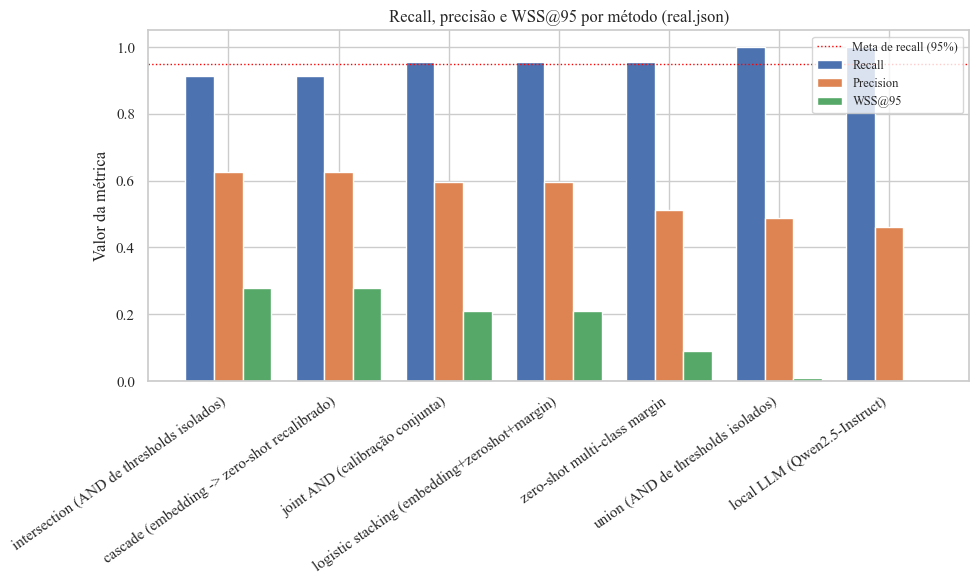

In [26]:
metrics_to_plot = comparison_v2[["recall", "precision", "wss"]].copy()
metrics_to_plot = metrics_to_plot.sort_values("wss", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(metrics_to_plot))
width = 0.26

ax.bar(x - width, metrics_to_plot["recall"], width, label="Recall")
ax.bar(x, metrics_to_plot["precision"], width, label="Precision")
ax.bar(x + width, metrics_to_plot["wss"], width, label="WSS@95")

ax.axhline(CONFIG["TARGET_RECALL"], color="red", linestyle=":", linewidth=1,
           label=f"Meta de recall ({CONFIG['TARGET_RECALL']:.0%})")
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot.index, rotation=35, ha="right")
ax.set_ylabel("Valor da métrica")
ax.set_title("Recall, precisão e WSS@95 por método (real.json)")
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

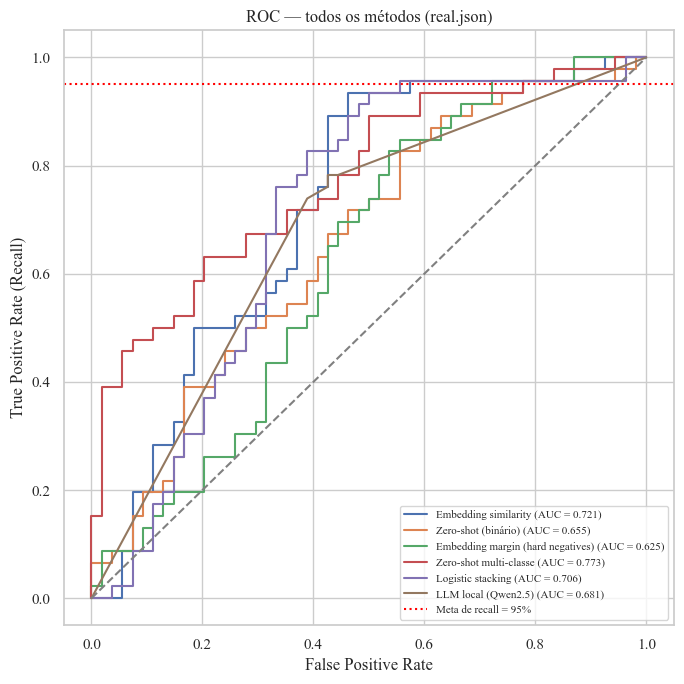

In [27]:
score_columns = [
    ("embedding_score", "Embedding similarity"),
    ("zeroshot_score", "Zero-shot (binário)"),
    ("embedding_margin_score", "Embedding margin (hard negatives)"),
    ("multiclass_margin_score", "Zero-shot multi-classe"),
    ("meta_score", "Logistic stacking"),
    ("llm_score", "LLM local (Qwen2.5)"),
]

fig, ax = plt.subplots(figsize=(7, 7))
for col, name in score_columns:
    if col not in df_real.columns:
        continue
    fpr, tpr, _ = roc_curve(df_real["label"], df_real[col])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.axhline(CONFIG["TARGET_RECALL"], color="red", linestyle=":", label=f"Meta de recall = {CONFIG['TARGET_RECALL']:.0%}")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC — todos os métodos (real.json)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

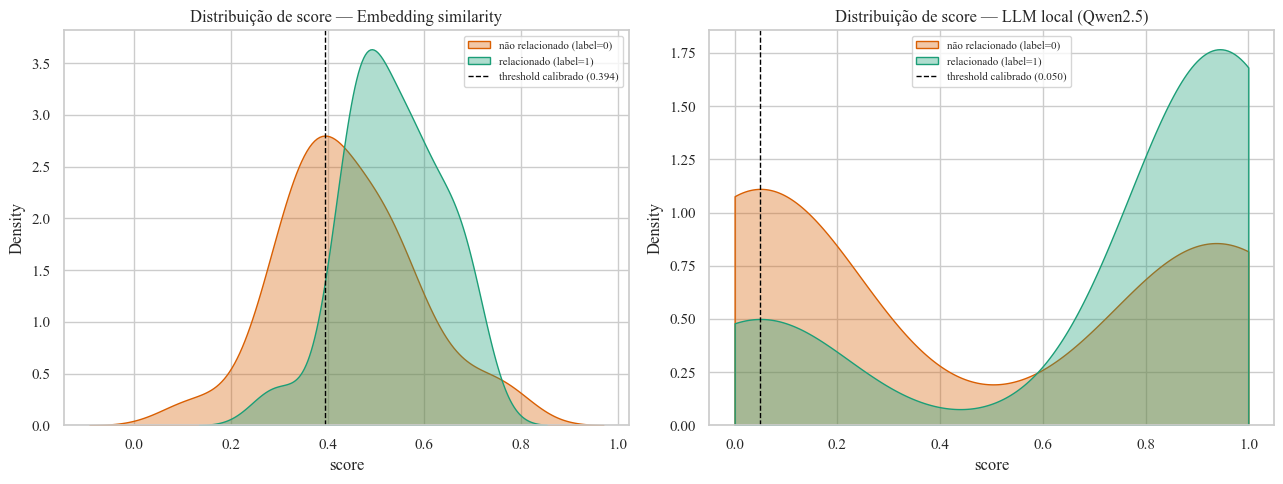

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, (col, name) in zip(axes, [("embedding_score", "Embedding similarity"), ("llm_score", "LLM local (Qwen2.5)")]):
    for label_value, label_name, color in [(0, "não relacionado (label=0)", "#d95f02"),
                                            (1, "relacionado (label=1)", "#1b9e77")]:
        subset = df_real.loc[df_real["label"] == label_value, col].dropna()
        sns.kdeplot(subset, ax=ax, fill=True, alpha=0.35, color=color, label=label_name, clip=(0, 1) if col != "embedding_score" else None)
    threshold = llm_stats["threshold"] if col == "llm_score" else embedding_stats["threshold"]
    ax.axvline(threshold, color="black", linestyle="--", linewidth=1, label=f"threshold calibrado ({threshold:.3f})")
    ax.set_title(f"Distribuição de score — {name}")
    ax.set_xlabel("score")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Escolha do método para o corpus completo

Por padrão, escolhe automaticamente o método com maior precisão entre os que atingem
o recall alvo (empate resolvido por WSS). Ajuste `CHOSEN_METHOD` manualmente se
preferir decidir você mesmo depois de olhar a tabela acima.

In [29]:
CHOSEN_METHOD = None  # None = escolha automática; ou "joint_and" / "meta"

candidates = {
    "joint_and": {"recall": joint_and_stats["recall"], "precision": joint_and_stats["precision"],
                  "wss": joint_and_stats["wss"]},
    "cascade": {"recall": cascade_stats["recall"], "precision": cascade_stats["precision"],
                "wss": cascade_stats["wss"]},
    "multiclass": {"recall": multiclass_stats["achieved_recall"],
                   "precision": comparison_v2.loc["zero-shot multi-class margin", "precision"]
                                 if "zero-shot multi-class margin" in comparison_v2.index else np.nan,
                   "wss": multiclass_stats["wss_at_target"]},
    "llm": {"recall": llm_stats["achieved_recall"],
            "precision": comparison_v2.loc["local LLM (Qwen2.5-Instruct)", "precision"]
                          if "local LLM (Qwen2.5-Instruct)" in comparison_v2.index else np.nan,
            "wss": llm_stats["wss_at_target"]},
    "meta": {"recall": meta_stats["achieved_recall"],
             "precision": comparison_v2.loc["logistic stacking (embedding+zeroshot+margin)", "precision"],
             "wss": meta_stats["wss_at_target"]},
}

if CHOSEN_METHOD is None:
    eligible = {k: v for k, v in candidates.items() if v["recall"] >= CONFIG["TARGET_RECALL"] - 1e-9}
    pool = eligible if eligible else candidates
    CHOSEN_METHOD = max(pool, key=lambda k: (pool[k]["precision"], pool[k]["wss"]))

print(f"CHOSEN_METHOD = {CHOSEN_METHOD!r}")
print(candidates[CHOSEN_METHOD])

CHOSEN_METHOD = 'joint_and'
{'recall': 0.9565217391304348, 'precision': 0.5945945945945946, 'wss': 0.20999999999999996}


### Matriz de confusão do método escolhido (`real.json`)

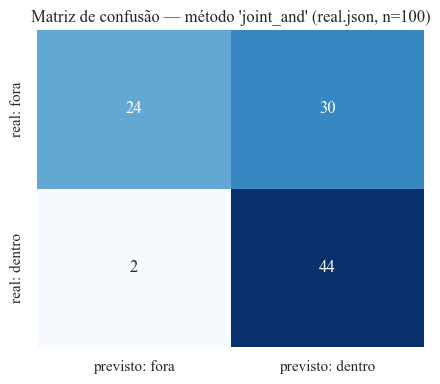

In [30]:
chosen_stats_map = {
    "joint_and": joint_and_stats, "cascade": cascade_stats,
    "meta": meta_stats, "multiclass": multiclass_stats, "llm": llm_stats,
}
chosen_stats = chosen_stats_map[CHOSEN_METHOD]
# meta/multiclass/llm store keys as tn/fp/fn/tp via wss_at_recall(); joint_and/cascade already match.
cm = np.array([[chosen_stats["tn"], chosen_stats["fp"]],
               [chosen_stats["fn"], chosen_stats["tp"]]])

fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["previsto: fora", "previsto: dentro"],
            yticklabels=["real: fora", "real: dentro"], ax=ax)
ax.set_title(f"Matriz de confusão — método '{CHOSEN_METHOD}' (real.json, n={len(df_real)})")
plt.tight_layout()
plt.show()

## Step 2 — Apply the calibrated methods to the full corpus

Mesmo arquivo usado pelo notebook original (`MAIN_DATA_PATH`). Calcula os três scores
(embedding, zero-shot, margem com âncoras negativas) e as seis colunas de decisão:
as quatro originais (auditoria) mais `is_walkability_joint_and` e `is_walkability_meta`
(as duas correções da seção anterior), e `is_walkability_recommended`, que aponta para
o método escolhido automaticamente com base na precisão no `real.json` entre os que
atingem o recall alvo.

In [31]:
with open(CONFIG["MAIN_DATA_PATH"], "r", encoding="utf8") as f:
    corpus_data = json.load(f)

df_corpus = pd.DataFrame(corpus_data)
df_corpus["text"] = df_corpus.apply(lambda r: get_text(r.to_dict()), axis=1)

missing = df_corpus["text"].isna().sum()
if missing:
    print(f"WARNING: {missing}/{len(df_corpus)} corpus records have no usable text field "
          f"— these will be scored as not-related by default.")

print(f"Loaded {len(df_corpus)} corpus records")
df_corpus.head(3)

Loaded 1445 corpus records


,title,authors,journal,doi,publication_date,document_type,prism:url,scopus_id,abstract,author_keywords,subject_areas,introduction,contribution,text
0,Intelligent assessment and diagnosis of street space quality using visual transformers,Xie J.,Discover Artificial Intelligence,10.1007/s44163-026-01409-7,2026,Article,https://api.elsevier.com/content/abstract/scopus_id/105045280156,105045280156,"Addressing the demand for street-level spatial renewal in the context of high-quality urban development, this paper establishes an intelligent assessment and diagnosis framework for street-level spatial quality that integrates visual Transformers. First, we propose the Progressive Local Feature ...","[Machine learning evaluation, Semantic segmentation, Street-level spatial quality, TrueSkill algorithm, Visual transformer]","[Information Systems, Human-Computer Interaction, Computer Vision and Pattern Recognition, Artificial Intelligence]","Addressing the demand for street-level spatial renewal in the context of high-quality urban development, this paper establishes an intelligent assessment and diagnosis framework for street-level spatial quality that integrates visual Transformers.","Addressing the demand for street-level spatial renewal in the context of high-quality urban development, this paper establishes an intelligent assessment and diagnosis framework for street-level spatial quality that integrates visual Transformers. First, we propose the Progressive Local Feature ...","Addressing the demand for street-level spatial renewal in the context of high-quality urban development, this paper establishes an intelligent assessment and diagnosis framework for street-level spatial quality that integrates visual Transformers. First, we propose the Progressive Local Feature ..."
1,"More trees, more restorativeness? Exploring the influence of campus pedestrian space on stress recovery using street view imagery",Mai S.,Computational Urban Science,10.1007/s43762-026-00286-1,2026,Article,https://api.elsevier.com/content/abstract/scopus_id/105046083709,105046083709,"Campus pedestrian environments play a critical role in alleviating student stress through environmental factors. According to Stress Recovery Theory (SRT), visual exposure to natural elements may trigger restorative psychological responses. However, previous studies have rarely compared multiple...","[Computer vision, Restoration, Street-view imagery, Stress recovery, Walkable campus environments]","[Environmental Science (miscellaneous), Urban Studies, Computer Science Applications, Artificial Intelligence]","Campus pedestrian environments play a critical role in alleviating student stress through environmental factors. According to Stress Recovery Theory (SRT), visual exposure to natural elements may trigger restorative psychological responses. However, previous studies have rarely compared multiple...","To address these gaps, we propose a scalable approach combining street-view imagery (SVI) and machine learning to evaluate the restorative quality of campus pedestrian environments. Across four Nanning campuses, we quantified visual features from 1060 street-view images, then paired these with o...","To address these gaps, we propose a scalable approach combining street-view imagery (SVI) and machine learning to evaluate the restorative quality of campus pedestrian environments. Across four Nanning campuses, we quantified visual features from 1060 street-view images, then paired these with o..."
2,Examining streetscape visuals and emotional responses through social media and street view image analysis,Yang X.,International Journal of Health Geographics,10.1186/s12942-025-00440-8,2026,Article,https://api.elsevier.com/content/abstract/scopus_id/105030690154,105030690154,"Background: Streets are important spaces for everyday activities, and the street environment can impact quality of life. This study investigates the impact of streetscape visuals on public emotions in the Beishan Stre

In [32]:
# ============================================================
# Aplicar somente o método escolhido ao corpus completo
# ============================================================

print(f"Aplicando somente o método escolhido: {CHOSEN_METHOD!r}")

def has_text(value):
    return isinstance(value, str) and bool(value.strip())


if CHOSEN_METHOD == "joint_and":
    # Necessita dos scores de embedding e zero-shot.
    tqdm.pandas(desc="Embedding similarity (full corpus)")
    df_corpus["embedding_score"] = df_corpus["text"].progress_apply(
        lambda t: embedding_score(t) if has_text(t) else np.nan
    )

    tqdm.pandas(desc="Zero-shot classification (full corpus)")
    df_corpus["zeroshot_score"] = df_corpus["text"].progress_apply(
        lambda t: zeroshot_score(t) if has_text(t) else np.nan
    )

    df_corpus["is_walkability_recommended"] = (
        (df_corpus["embedding_score"] >= joint_and_stats["threshold_a"])
        & (df_corpus["zeroshot_score"] >= joint_and_stats["threshold_b"])
    )


elif CHOSEN_METHOD == "cascade":
    # Estágio 1: embedding.
    tqdm.pandas(desc="Embedding — cascade stage 1")
    df_corpus["embedding_score"] = df_corpus["text"].progress_apply(
        lambda t: embedding_score(t) if has_text(t) else np.nan
    )

    # Estágio 2: zero-shot somente nos sobreviventes do embedding.
    stage1_mask = (
        df_corpus["embedding_score"] >= cascade_stats["threshold_a"]
    )

    df_corpus["zeroshot_score"] = np.nan

    tqdm.pandas(desc="Zero-shot — cascade stage 2")
    df_corpus.loc[stage1_mask, "zeroshot_score"] = (
        df_corpus.loc[stage1_mask, "text"].progress_apply(
            lambda t: zeroshot_score(t) if has_text(t) else np.nan
        )
    )

    df_corpus["is_walkability_recommended"] = (
        stage1_mask
        & (
            df_corpus["zeroshot_score"]
            >= cascade_stats["threshold_b"]
        )
    )


elif CHOSEN_METHOD == "meta":
    # O stacking precisa dos três scores usados durante seu treinamento.
    tqdm.pandas(desc="Embedding similarity (full corpus)")
    df_corpus["embedding_score"] = df_corpus["text"].progress_apply(
        lambda t: embedding_score(t) if has_text(t) else np.nan
    )

    tqdm.pandas(desc="Zero-shot classification (full corpus)")
    df_corpus["zeroshot_score"] = df_corpus["text"].progress_apply(
        lambda t: zeroshot_score(t) if has_text(t) else np.nan
    )

    tqdm.pandas(desc="Embedding margin (full corpus)")
    df_corpus["embedding_margin_score"] = df_corpus["text"].progress_apply(
        lambda t: embedding_margin_score(t) if has_text(t) else np.nan
    )

    X_corpus = (
        df_corpus[
            [
                "embedding_score",
                "zeroshot_score",
                "embedding_margin_score",
            ]
        ]
        .fillna(0.0)
        .to_numpy()
    )

    df_corpus["meta_score"] = meta_clf.predict_proba(X_corpus)[:, 1]

    df_corpus["is_walkability_recommended"] = (
        df_corpus["meta_score"] >= meta_stats["threshold"]
    )


elif CHOSEN_METHOD == "multiclass":
    # Executa somente o zero-shot multiclass.
    tqdm.pandas(desc="Multi-class zero-shot (full corpus)")
    corpus_multiclass_raw = df_corpus["text"].progress_apply(
        lambda t: (
            multiclass_scores(t)
            if has_text(t)
            else {label: np.nan for label in MULTICLASS_TEXTS}
        )
    )

    for key in MULTICLASS_ORDER:
        label_text = MULTICLASS_LABELS[key]
        df_corpus[f"mc_{key}"] = corpus_multiclass_raw.apply(
            lambda scores: scores[label_text]
        )

    corpus_competing_cols = [
        f"mc_{key}"
        for key in MULTICLASS_ORDER
        if key != "target"
    ]

    df_corpus["multiclass_margin_score"] = (
        df_corpus["mc_target"]
        - df_corpus[corpus_competing_cols].max(axis=1)
    )

    df_corpus["is_walkability_recommended"] = (
        df_corpus["multiclass_margin_score"]
        >= multiclass_stats["threshold"]
    )


elif CHOSEN_METHOD == "llm":
    # Classificação com o LLM local (Qwen2.5-Instruct), sem custo de API — em lote
    # (LLM_BATCH_SIZE), a mesma função usada na calibração contra o real.json.
    corpus_llm_results = run_llm_on_texts(
        df_corpus["text"], batch_size=LLM_BATCH_SIZE, desc="Local LLM classification (full corpus)"
    )

    df_corpus["llm_score"] = [r[0] for r in corpus_llm_results]
    df_corpus["llm_decision"] = [r[1] for r in corpus_llm_results]
    df_corpus["llm_rationale"] = [r[2] for r in corpus_llm_results]

    df_corpus["is_walkability_recommended"] = (
        df_corpus["llm_score"] >= llm_stats["threshold"]
    )


else:
    raise ValueError(
        f"CHOSEN_METHOD desconhecido: {CHOSEN_METHOD!r}"
    )


selected = int(df_corpus["is_walkability_recommended"].sum())
total = len(df_corpus)

print(
    f"\nMétodo aplicado: {CHOSEN_METHOD}"
    f"\nSelecionados: {selected}/{total} "
    f"({selected / total * 100:.2f}%)"
)

Aplicando somente o método escolhido: 'joint_and'


Embedding similarity (full corpus):   0%|          | 0/1445 [00:00<?, ?it/s]

Zero-shot classification (full corpus):   0%|          | 0/1445 [00:00<?, ?it/s]


Método aplicado: joint_and
Selecionados: 968/1445 (66.99%)


## Visualização — resultado no corpus completo

Proporção do corpus retida vs. descartada pelo método escolhido, e a distribuição do
score do método escolhido em todo o corpus (não só no `real.json`) — útil para ver se
a maior parte dos registros está próxima do threshold (zona de incerteza, vale conferir
manualmente uma amostra) ou claramente separada em dois grupos.

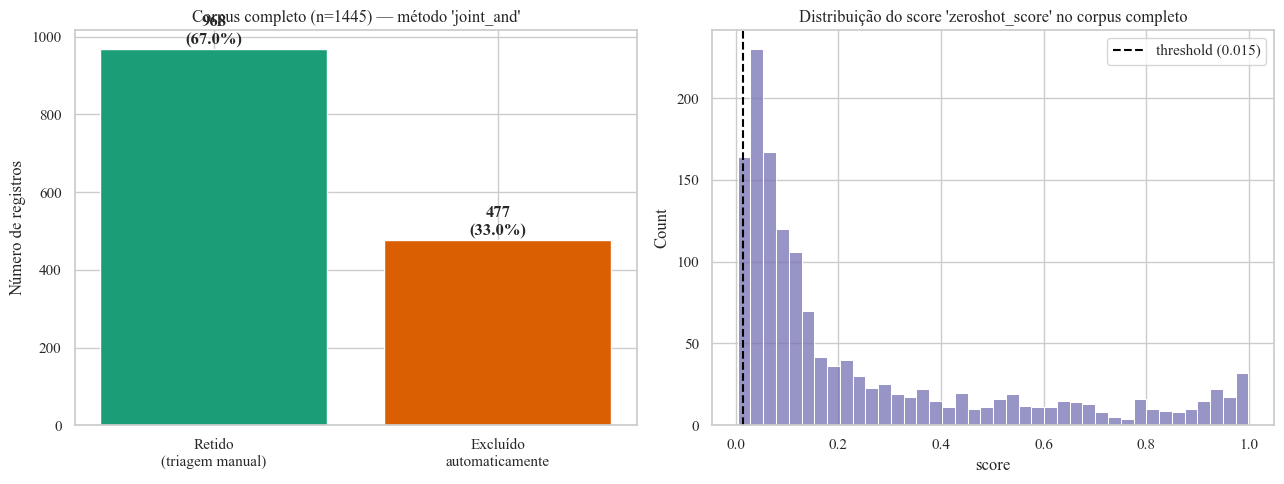

In [33]:
score_col_by_method = {
    "joint_and": "zeroshot_score", "cascade": "zeroshot_score",
    "meta": "meta_score", "multiclass": "multiclass_margin_score", "llm": "llm_score",
}
threshold_by_method = {
    "joint_and": joint_and_stats["threshold_b"], "cascade": cascade_stats["threshold_b"],
    "meta": meta_stats["threshold"], "multiclass": multiclass_stats["threshold"], "llm": llm_stats["threshold"],
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) Retained vs. excluded, as a simple proportion
counts = df_corpus["is_walkability_recommended"].value_counts()
counts = counts.reindex([True, False], fill_value=0)
axes[0].bar(["Retido\n(triagem manual)", "Excluído\nautomaticamente"], counts.values,
            color=["#1b9e77", "#d95f02"])
for i, v in enumerate(counts.values):
    axes[0].text(i, v + total * 0.01, f"{v}\n({v/total*100:.1f}%)", ha="center", fontweight="bold")
axes[0].set_title(f"Corpus completo (n={total}) — método '{CHOSEN_METHOD}'")
axes[0].set_ylabel("Número de registros")

# (b) Score distribution across the full corpus, with the calibrated threshold marked
score_col = score_col_by_method[CHOSEN_METHOD]
threshold = threshold_by_method[CHOSEN_METHOD]
sns.histplot(df_corpus[score_col].dropna(), bins=40, ax=axes[1], color="#7570b3")
axes[1].axvline(threshold, color="black", linestyle="--", linewidth=1.5,
                 label=f"threshold ({threshold:.3f})")
axes[1].set_title(f"Distribuição do score '{score_col}' no corpus completo")
axes[1].set_xlabel("score")
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 3 — Save results

Salva três artefatos em `OUTPUT_DIR`:

1. `05_full_corpus_with_embedding_zeroshot_scores.json` — corpus completo com os dois
   scores e as quatro colunas de decisão, para auditoria e reprodutibilidade.
2. `05_filtered_walkability_applications.json` — subconjunto filtrado (critério union,
   mesmo nome de arquivo do notebook original, para não quebrar o resto do pipeline).
3. `05_validation_metrics.json` — as métricas de validação no `real.json` (recall,
   precision, F1, WSS@95, thresholds), para documentar a decisão no protocolo PRISMA.

In [34]:
# ============================================================
# Salvar resultados
# ============================================================

FILTER_COLUMN = "is_walkability_recommended"

output_full_path = os.path.join(
    CONFIG["OUTPUT_DIR"],
    "05_full_corpus_with_embedding_zeroshot_scores.json",
)

output_filtered_path = os.path.join(
    CONFIG["OUTPUT_DIR"],
    "05_filtered_walkability_applications.json",
)

output_metrics_path = os.path.join(
    CONFIG["OUTPUT_DIR"],
    "05_validation_metrics.json",
)

# Salva o corpus completo, incluindo scores e decisão final.
df_corpus.to_json(
    output_full_path,
    orient="records",
    indent=4,
    force_ascii=False,
)

# Salva somente os registros aprovados pelo método escolhido.
filtered = df_corpus[df_corpus[FILTER_COLUMN] == True].copy()

filtered.to_json(
    output_filtered_path,
    orient="records",
    indent=4,
    force_ascii=False,
)

# Métricas e configurações dos métodos avaliados.
metrics_report = {
    "target_recall": CONFIG["TARGET_RECALL"],
    "real_json_n": len(df_real),
    "real_json_n_positive": int(df_real["label"].sum()),

    "embedding": {
        **embedding_stats,
        "model": CONFIG["EMBEDDING_MODEL_NAME"],
        "anchor": CONFIG["POSITIVE_ANCHOR"],
    },

    "zeroshot": {
        **zeroshot_stats,
        "model": CONFIG["ZEROSHOT_MODEL_NAME"],
        "candidate_labels": CONFIG["ZEROSHOT_CANDIDATE_LABELS"],
        "hypothesis_template": CONFIG["ZEROSHOT_HYPOTHESIS_TEMPLATE"],
    },

    "embedding_margin": {
        **margin_stats,
        "hard_negative_anchors": HARD_NEGATIVE_ANCHORS,
    },

    "joint_and_calibration": joint_and_stats,
    "cascade": cascade_stats,

    "multiclass_margin": {
        **multiclass_stats,
        "labels": MULTICLASS_LABELS,
    },

    "logistic_stacking": {
        **meta_stats,
        "features": [
            "embedding_score",
            "zeroshot_score",
            "embedding_margin_score",
        ],
    },

    "local_llm": {
        **llm_stats,
        "model": LLM_MODEL_NAME,
        "system_prompt": LLM_SYSTEM_PROMPT,
    },

    "chosen_method": CHOSEN_METHOD,
    "corpus_filter_column_used": FILTER_COLUMN,
    "corpus_n_total": len(df_corpus),
    "corpus_n_filtered": len(filtered),
}

with open(output_metrics_path, "w", encoding="utf-8") as f:
    json.dump(
        metrics_report,
        f,
        indent=2,
        ensure_ascii=False,
    )

print(f"Método escolhido: {CHOSEN_METHOD}")
print(f"Total de registros: {len(df_corpus)}")
print(
    f"Registros filtrados: {len(filtered)} "
    f"({len(filtered) / len(df_corpus) * 100:.2f}%)"
)

print("\nArquivos salvos:")
print(f"  Corpus completo: {output_full_path}")
print(f"  Corpus filtrado: {output_filtered_path}")
print(f"  Métricas:        {output_metrics_path}")

Método escolhido: joint_and
Total de registros: 1445
Registros filtrados: 968 (66.99%)

Arquivos salvos:
  Corpus completo: ../data\05_full_corpus_with_embedding_zeroshot_scores.json
  Corpus filtrado: ../data\05_filtered_walkability_applications.json
  Métricas:        ../data\05_validation_metrics.json
